# Midterm Exam

## Grading Rubric

Each question is worth 20 points. The answer to each question will be graded in terms of:


* Correct Analysis & Computation `(8 points)`
  - Correct use of pandas operations (groupby, aggregation, filtering).
  - Accurate statistics or summaries.

* Appropriate Use of Visuals / Tables — `(6 points)`
  - Visualization or table is relevant to the question.
  - Plot type is appropriate (bar, boxplot, line, etc.).
  - Labels and axes are clear.


* Interpretation and Reasoning — `(6 points)`
  - Conclusions are clearly stated.
  - Interpretations are supported by data.
  - Reasoning is logical and coherent.

## Variable Definitions

* **hotel**
  - H1 = Resort Hotel
  - H2 = City Hotel

* **is_canceled** - Value indicating if the booking was canceled.
  - (1) canceled
  - (0) not canceled

* **lead_time** - Number of days that elapsed between the entering date of the booking into the PMS and the arrival date

* **arrival_date_year** - Year of arrival date

* **arrival_date_month** - Month of arrival date

* **arrival_date_week_number** - Week number of year for arrival date

* **arrival_date_day_of_month** - Day of arrival date

* **stays_in_weekend_nights** - Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel

* **stays_in_week_nights** - Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel

* **adults** - Number of adults

* **children** - Number of children

* **babies** - Number of babies

* **meal** - Type of meal booked. Categories are presented in standard hospitality meal packages:
  - Undefined/SC – no meal package.
  - BB – Bed & Breakfast.
  - HB – Half board (breakfast and one other meal – usually dinner).
  - FB – Full board (breakfast, lunch and dinner)

* **country** - Country of origin. Categories are represented in the ISO 3155–3:2013 format

* **market_segment** - Market segment designation. In categories, the term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **distribution_channel** - Booking distribution channel. The term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **is_repeated_guest** - Value indicating if the booking name was from a repeated guest.
  - 1 is a repeated guest.
  - 0 is not a repeated guest.

* **previous_cancellations** - Number of previous bookings that were cancelled by the customer prior to the current booking

* **previous_bookings_not_canceled** - Number of previous bookings not cancelled by the customer prior to the current booking

* **reserved_room_type** - Code of room type reserved. Code is presented instead of designation for anonymity reasons.

* **assigned_room_type** - Code for the type of room assigned to the booking. Sometimes the assigned room type differs from the reserved room type due to hotel operation reasons (e.g. overbooking) or by customer request. Code is presented instead of designation for anonymity reasons.

* **booking_changes** - Number of changes/amendments made to the booking from the moment the booking was entered on the PMS until the moment of check-in or cancellation

* **deposit_type** - Indication on if the customer made a deposit to guarantee the booking. This variable can assume three categories:

  - No Deposit – no deposit was made.
  - Non Refund – a deposit was made in the value of the total stay cost.  
  - Refundable – a deposit was made with a value under the total cost of stay.

* **agent** - ID of the travel agency that made the booking

* **company** - ID of the company/entity that made the booking or responsible for paying the booking. ID is presented instead of designation for anonymity reasons

* **days_in_waiting_list** - Number of days the booking was in the waiting list before it was confirmed to the customer

* **customer_type** - Type of booking, assuming one of four categories:   

  - Contract - when the booking has an allotment or other type of contract associated to it.
  - Group – when the booking is associated to a group.
  - Transient – when the booking is not part of a group or contract, and is not associated to other transient booking.
  - Transient-party – when the booking is transient, but is associated to at least other transient booking

* **adr** - Average Daily Rate as defined by dividing the sum of all lodging transactions by the total number of staying nights

* **required_car_parking_spaces** - Number of car parking spaces required by the customer

* **total_of_special_requests** - Number of special requests made by the customer (e.g. twin bed or high floor)

* **reservation_status** - Reservation last status, assuming one of three categories:
  - Canceled – booking was canceled by the customer.
  - Check-Out – customer has checked in but already departed.
  - No-Show – customer did not check-in and did inform the hotel of the reason why

* **reservation_status_date** - Date at which the last status was set. This variable can be used in conjunction with the ReservationStatus to

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\INAnokananaman\.cache\kagglehub\datasets\jessemostipak\hotel-booking-demand\versions\1


In [3]:
import os
import pandas as pd
import matplotlib as plt
from pandas.plotting import lag_plot, autocorrelation_plot, scatter_matrix

if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Dataset Overview & Core Distributions `(20 points)`

**Question:** What do the shapes and spread of the `lead_time` and `adr` distributions suggest about typical booking behavior and extreme cases in this dataset?

Perform an exploratory analysis of the distributional characteristics of key numerical variables in the hotel booking dataset.

You must:
- Analyze the distribution of lead_time and adr
- Use appropriate summary statistics and visualizations to support your analysis
- Identify any skewness and/or outliers in these variables

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   hotel                           119390 non-null  object  
 1   is_canceled                     119390 non-null  int64   
 2   lead_time                       119390 non-null  int64   
 3   arrival_date_year               119390 non-null  int64   
 4   arrival_date_month              119390 non-null  object  
 5   arrival_date_week_number        119390 non-null  int64   
 6   arrival_date_day_of_month       119390 non-null  int64   
 7   stays_in_weekend_nights         119390 non-null  int64   
 8   stays_in_week_nights            119390 non-null  int64   
 9   adults                          119390 non-null  int64   
 10  children                        119386 non-null  float64 
 11  babies                          119390 non-null  int64   
 12  me

In [6]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [7]:
df_concat_hotelLT= pd.concat([df['lead_time'],df['adr']],axis=1)
df_concat_hotelLT

,lead_time,adr
0,342,0.00
1,737,0.00
2,7,75.00
3,13,75.00
4,14,98.00
...,...,...
119385,23,96.14
119386,102,225.43
119387,34,157.71
119388,109,104.40


<Axes: title={'center': 'Graph 1. Lead Time ADR table'}, xlabel='lead_time', ylabel='adr'>

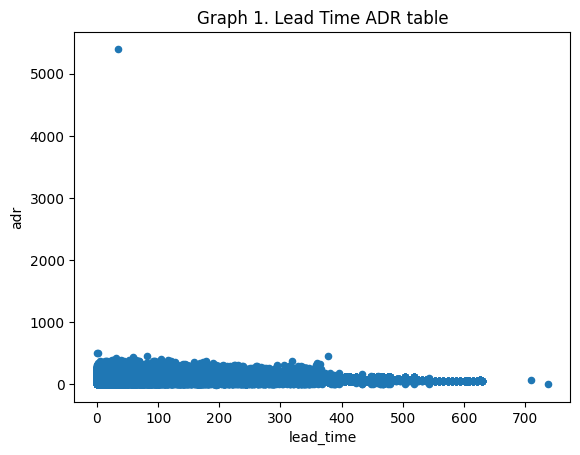

In [8]:
df_concat_hotelLT.plot.scatter(title='Graph 1. Lead Time ADR table',x='lead_time',y='adr')

<Axes: title={'center': 'Graph 2. Lead Time Histogram'}, xlabel='Lead Time', ylabel='Frequency'>

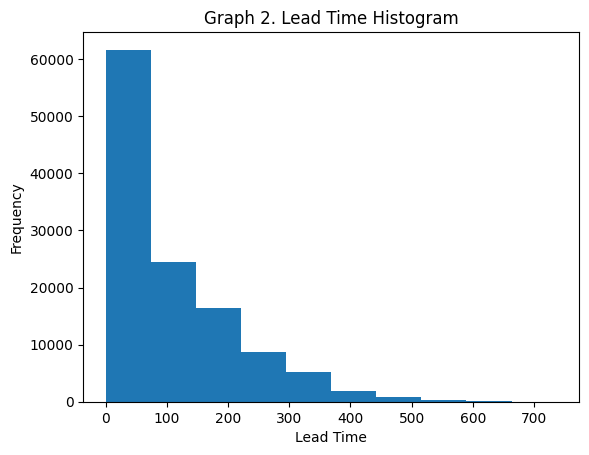

In [9]:
df['lead_time'].plot.hist(title='Graph 2. Lead Time Histogram',xlabel="Lead Time",ylabel="Frequency")

<Axes: title={'center': 'Graph 3. ADR Histogram'}, xlabel='ADR', ylabel='Frequency'>

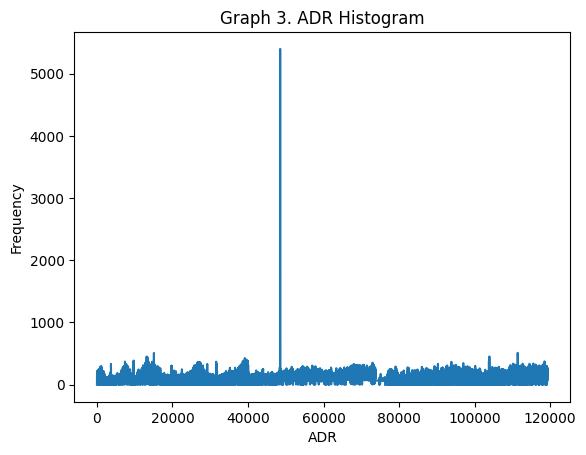

In [10]:
df['adr'].plot(title='Graph 3. ADR Histogram',xlabel="ADR",ylabel="Frequency")

In [11]:
# Table 1. ADR Central Tendency

def get_mode(s):
    return s.mode().iloc[0]

adr_cent = pd.DataFrame(df['adr'].agg(mean = 'mean', median = 'median' , mode = get_mode))
adr_cent


,adr
mean,101.831122
median,94.575000
mode,62.000000


In [12]:
# Table 2. Lead Time Central Tendency

def get_mode(s):
    return s.mode().iloc[0]

lT_cent = pd.DataFrame(df['lead_time'].agg(mean = 'mean', median = 'median' , mode = get_mode))
lT_cent

,lead_time
mean,104.011416
median,69.000000
mode,0.000000


In [13]:
# Table 3. Lead Time Central Tendencies
max_adr = df['adr'].max()
min_adr = df['adr'].min()

max_lT = df['lead_time'].max()
min_lT = df['lead_time'].min()

print('Max ADR = ',max_adr,'\nMin ADR = ',min_adr,'\nMax lT = ',max_lT,'\nMin lT = ',min_lT,)

Max ADR =  5400.0 
Min ADR =  -6.38 
Max lT =  737 
Min lT =  0


In [14]:
# Table 4. Lead Time Central Tendencies
df['adr'].quantile([0.25,0.50,0.75])

0.25     69.290
0.50     94.575
0.75    126.000
Name: adr, dtype: float64

In [15]:
# Table 5. Lead Time Central Tendencies

df['lead_time'].quantile([0.25,0.50,0.75])

0.25     18.0
0.50     69.0
0.75    160.0
Name: lead_time, dtype: float64

In [16]:
df_concat_hotelLT.shape

(119390, 2)

## ANALYSIS

To conclude this analysis, the data on table 1 shows that the longer the lead time of the client the more likely that the the ADR of the hotel would plummet due to low occupancy rates as seen in Graph 2.According to table 5. and Table 2 it shows that the majority of the transactions are below 104 Days which is the average, meaning that the data is skewed to the left, making it positively skewed. Although are some cases of extreme scenarios where the customer books and urgently check ins to hotel the ADR of the hotel rises up due to demand that is caused by the massive number of bookings and low lead times. This is most likely because most customers prefer to book and check in within a short lead time occupying most rooms if not all, and if all rooms are occupied room prices can go up due to the demand making the ADR spike in the graph.

Finally, the spreads of the lead_time and adr graphs distribution shows that most transactions that are done with shorter lead times are where the ADR usually averages, althought there are some cases of outliers where the maximum occupancy could be full making the prices of the rooms go higher and making the ADR rise up too. There are also cases where the transaction rates are low where it can be directly correlated to the longer lead time specifying the booking in advance months before can actually lead to cancellations of the booking or lower rates for each room making the ADR lower than the average. The Distributions suggest that lead time can affect the ADR of the hotel gradually due to multiple factors, it also suggests that the guests that book and urgently check ins (those that had lead times below 160) are the within the 0.75 percentile of all transactions making them the majority.

## 2. Booking Cancellations and Lead Time `(20 points)`

**Question**: Do bookings with longer lead times tend to cancel more often?

Analyze how `lead_time` differs between canceled and non-canceled bookings.

You must:
- Compute appropriate summary statistics
- Use at least one visualization
- Clearly describe the pattern you observe



In [13]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [53]:
df.groupby('is_canceled')['lead_time'].quantile([0.25,0.50,0.75]).unstack()
df['bin'] = pd.cut(
    df['lead_time'],
    include_lowest=True,
    bins=[0,0.30,90,180,365,800])

In [54]:
df.groupby('bin')['is_canceled'].mean().reset_index(name='cancelled_val')

C:\Users\INAnokananaman\AppData\Local\Temp\ipykernel_4828\297085473.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('bin')['is_canceled'].mean().reset_index(name='cancelled_val')


,bin,cancelled_val
0,"(-0.001, 0.3]",0.067770
1,"(0.3, 90.0]",0.289046
2,"(90.0, 180.0]",0.447105
3,"(180.0, 365.0]",0.554540
4,"(365.0, 800.0]",0.676620


In [55]:
# Table 1. Lead Time Central Tendencies
df['is_canceled'].quantile([0.25,0.50,0.75])

0.25    0.0
0.50    0.0
0.75    1.0
Name: is_canceled, dtype: float64

In [56]:
# Table 2. Lead Time Central Tendencies
df['lead_time'].quantile([0.25,0.50,0.75])

0.25     18.0
0.50     69.0
0.75    160.0
Name: lead_time, dtype: float64

In [57]:
cancelled_val = df.groupby('lead_time')['is_canceled'].mean().reset_index(name='cancelled_val')
cancelled_val

,lead_time,cancelled_val
0,0,0.067770
1,1,0.092775
2,2,0.102948
3,3,0.100220
4,4,0.102624
...,...,...
474,622,1.000000
475,626,1.000000
476,629,1.000000
477,709,0.000000


<Axes: title={'center': 'Graph 1. Number of Cancellations Against Lead Time'}, xlabel='lead_time', ylabel='cancelled_val'>

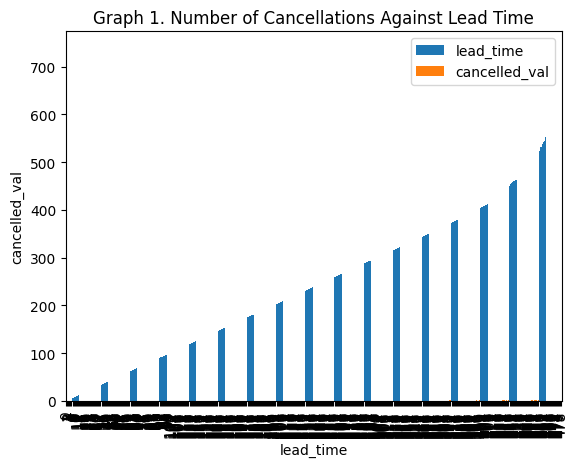

In [59]:
cancelled_val.plot.bar(title='Graph 1. Number of Cancellations Against Lead Time',xlabel='lead_time',ylabel='cancelled_val')

## Analysis

Based on the Graph itself, it shows that the longer the lead time, the higher the chance that people would likely cancel their booking. Based on the data, about 0.75 percentile of the amount of people that cancels have lead times of below 160 Days.

## 3. Seasonality and Pricing `(20 points)`

**Question**: Do `Resort Hotels` and `City Hotels` exhibit different seasonal pricing behaviors throughout the year? If so, during which months are these differences most pronounced?

Analyze how Average Daily Rate (ADR) varies across arrival months, and compare this pattern between Resort Hotels and City Hotels.

You must:
- Aggregate ADR by month and hotel type
- Use a visualization to support your analysis
- Identify at least one seasonal pricing pattern

In [77]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bin
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,"(180.0, 365.0]"
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,"(365.0, 800.0]"
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,"(0.3, 90.0]"
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,"(0.3, 90.0]"
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,"(0.3, 90.0]"


In [66]:
df['hotel'].unique()

array(['Resort Hotel', 'City Hotel'], dtype=object)

In [89]:
monthly_adr = df.groupby(['hotel','arrival_date_month'])['adr'].mean().reset_index()
monthly_adr

,hotel,arrival_date_month,adr
0,City Hotel,April,111.251838
1,City Hotel,August,114.680455
2,City Hotel,December,88.826307
3,City Hotel,February,85.088278
4,City Hotel,January,82.628986
5,City Hotel,July,110.734292
6,City Hotel,June,119.074341
7,City Hotel,March,92.643116
8,City Hotel,May,121.638560
9,City Hotel,November,88.069601


In [103]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_adr['arrival_date_month'] = pd.Categorical(
    monthly_adr["arrival_date_month"],
    categories=month_order,
    ordered=True
)

In [109]:
adr_pivot = monthly_adr.pivot(index ='arrival_date_month', columns='hotel', values='adr')
print(adr_pivot)

hotel               City Hotel  Resort Hotel
arrival_date_month                          
January              82.628986     49.461883
February             85.088278     55.171930
March                92.643116     57.520147
April               111.251838     77.849496
May                 121.638560     78.758134
June                119.074341    110.444749
July                110.734292    155.181299
August              114.680455    186.790574
September           110.004661     93.252030
October              99.974498     62.097617
November             88.069601     48.273993
December             88.826307     68.984230


## Analysis



Resorts shows more pricing behaviors than City Hotel During Summer Months (June,July,August) due to the surge of turists occupying hotel rooms during their vacations. While City Hotels prices spike during April to September also overlapping to summer vacation.


## 4. Customer Behavior `(20 points)`

**Question:** Do repeated guests behave differently from first-time guests?

Compare repeated guests and non-repeated guests in terms of:
- Cancellation rate
- Booking behavior (e.g., booking changes or lead time)
- Use summary statistics and/or visualizations to support your answer.


In [91]:
df['is_canceled'].sum()

np.int64(44224)

In [112]:
behavior = (
    df.groupby('is_repeated_guest').agg(
        cancellation_rate = ('is_canceled','mean'),
        avg_lead_time = ('lead_time','mean'),
        median_lead_time_=('lead_time','median'),
        avg_booking_changes = ('booking_changes','mean')
    )

)

print(behavior)

                   cancellation_rate  avg_lead_time  median_lead_time_  \
is_repeated_guest                                                        
0                           0.377851     106.425221               72.0   
1                           0.144882      30.786352                3.0   

                   avg_booking_changes  
is_repeated_guest                       
0                             0.219692  
1                             0.264567  


## Analysis

Based on the table repeated are less likely to cancel based on the data. Non Repeated Guests have a  cancellation rate of  .377851 rate higher than those repeated guests which have 0.144882.

## 5. Booking Cancellation Insights `(20 points)`

**Question:** Which combination of variables appears to have the strongest relationship with booking cancellations, and how do these variables interact to influence the likelihood of a cancellation?


Using at least three variables from the dataset, identify one strong pattern related to booking cancellations.

Your answer must:
- Clearly state the pattern
- Explain how the variables interact
- Support the conclusion with data


In [114]:
pattern = df['lead_time_group'] = pd.cut(df['lead_time'],bins=[0, 30, 90, 180, 365, 800],labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'],include_lowest=True)

print(pattern)

0               Long
1          Very Long
2         Very Short
3         Very Short
4         Very Short
             ...    
119385    Very Short
119386        Medium
119387         Short
119388        Medium
119389          Long
Name: lead_time, Length: 119390, dtype: category
Categories (5, object): ['Very Short' < 'Short' < 'Medium' < 'Long' < 'Very Long']


## Analysis


It shows that the lead time and seasons are the main factors on why people are cancelling their bookings